# Equity Analysis of AI DR Screening Performance Across Demographic Subgroups

This notebook examines whether AI diabetic retinopathy (DR) screening tools
perform equitably across demographic subgroups in the Aotearoa New Zealand
context. Equitable AI deployment is a core concern for health systems, and is
central to obligations under Te Tiriti o Waitangi to address health disparities
experienced by Māori and Pacific peoples.

We stratify AI performance by:
1. **Ethnicity** — NZ European, Māori, Pacific peoples, Asian, Other
2. **NZDep quintile** — area-based socioeconomic deprivation (Atkinson et al., 2019)
3. **Intersectional subgroups** — ethnicity × deprivation

Two scenarios are compared:
- **Equal performance** — AI accuracy is uniform across subgroups (best case)
- **Differential performance** — AI accuracy varies by subgroup, reflecting
  evidence of underdiagnosis bias in underserved populations
  (Seyyed-Kalantari et al., 2021; Coyner et al., 2023)

**Why this matters for Aotearoa NZ:**
Māori and Pacific peoples experience higher rates of diabetes and diabetic
retinopathy (Simmons et al., 2007), are more likely to live in areas of high
deprivation (Loring et al., 2022), and have lower screening attendance
(Ramke et al., 2019). If AI screening tools perform less accurately for these
populations, they risk widening rather than narrowing existing health inequities.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.metrics import diagnostic_accuracy, roc_analysis
from src.equity import (
    stratified_performance,
    sensitivity_gap,
    compare_sensitivity_two_groups,
    intersectional_analysis,
    equity_summary,
)
from src.visualisation import (
    set_style,
    plot_stratified_metric,
    plot_equity_heatmap,
    plot_gap_chart,
    ETHNICITY_LABELS,
    ETHNICITY_PALETTE,
)

set_style()
%matplotlib inline

## 1. Load Data

We focus on **Tool A** (high-sensitivity autonomous AI, based on the IDx-DR
meta-analysis) as it represents the best-performing tool profile and is most
likely to be considered for national deployment.

In [2]:
df_equal = pd.read_csv("../data/predictions_tool_a_equal.csv")
df_diff = pd.read_csv("../data/predictions_tool_a_differential.csv")

print(f"Equal scenario: {len(df_equal):,} patients")
print(f"Differential scenario: {len(df_diff):,} patients")
print(f"\nReferable DR prevalence by ethnicity:")
prev = df_equal.groupby("ethnicity")["has_referable_dr"].agg(["count", "sum", "mean"])
prev.index = [ETHNICITY_LABELS.get(e, e) for e in prev.index]
prev.columns = ["n", "DR cases", "Prevalence"]
print(prev.to_string())

Equal scenario: 10,000 patients
Differential scenario: 10,000 patients

Referable DR prevalence by ethnicity:
                    n  DR cases  Prevalence
Asian            1844       130    0.070499
Māori            1611       219    0.135940
NZ European      4833       173    0.035796
Other             501        29    0.057884
Pacific peoples  1211       158    0.130471


## 2. Stratified Performance by Ethnicity

### 2.1 Equal Performance Scenario

In [3]:
# Ethnicity-stratified metrics — equal scenario
strat_equal = stratified_performance(df_equal, "ethnicity")
strat_equal["ethnicity_label"] = strat_equal["group"].map(ETHNICITY_LABELS)
print("Performance by ethnicity (EQUAL scenario):")
print(strat_equal[["ethnicity_label", "n", "n_positive", "sensitivity",
                    "specificity", "ppv", "npv", "auc"]].to_string(index=False))

Performance by ethnicity (EQUAL scenario):
ethnicity_label    n  n_positive  sensitivity  specificity      ppv      npv      auc
          Asian 1844         130     0.938462     0.938156 0.535088 0.995050 0.982879
          Māori 1611         219     0.931507     0.930316 0.677741 0.988550 0.985655
    NZ European 4833         173     0.942197     0.933691 0.345339 0.997707 0.986653
          Other  501          29     0.862069     0.940678 0.471698 0.991071 0.969316
Pacific peoples 1211         158     0.924051     0.931624 0.669725 0.987915 0.983267


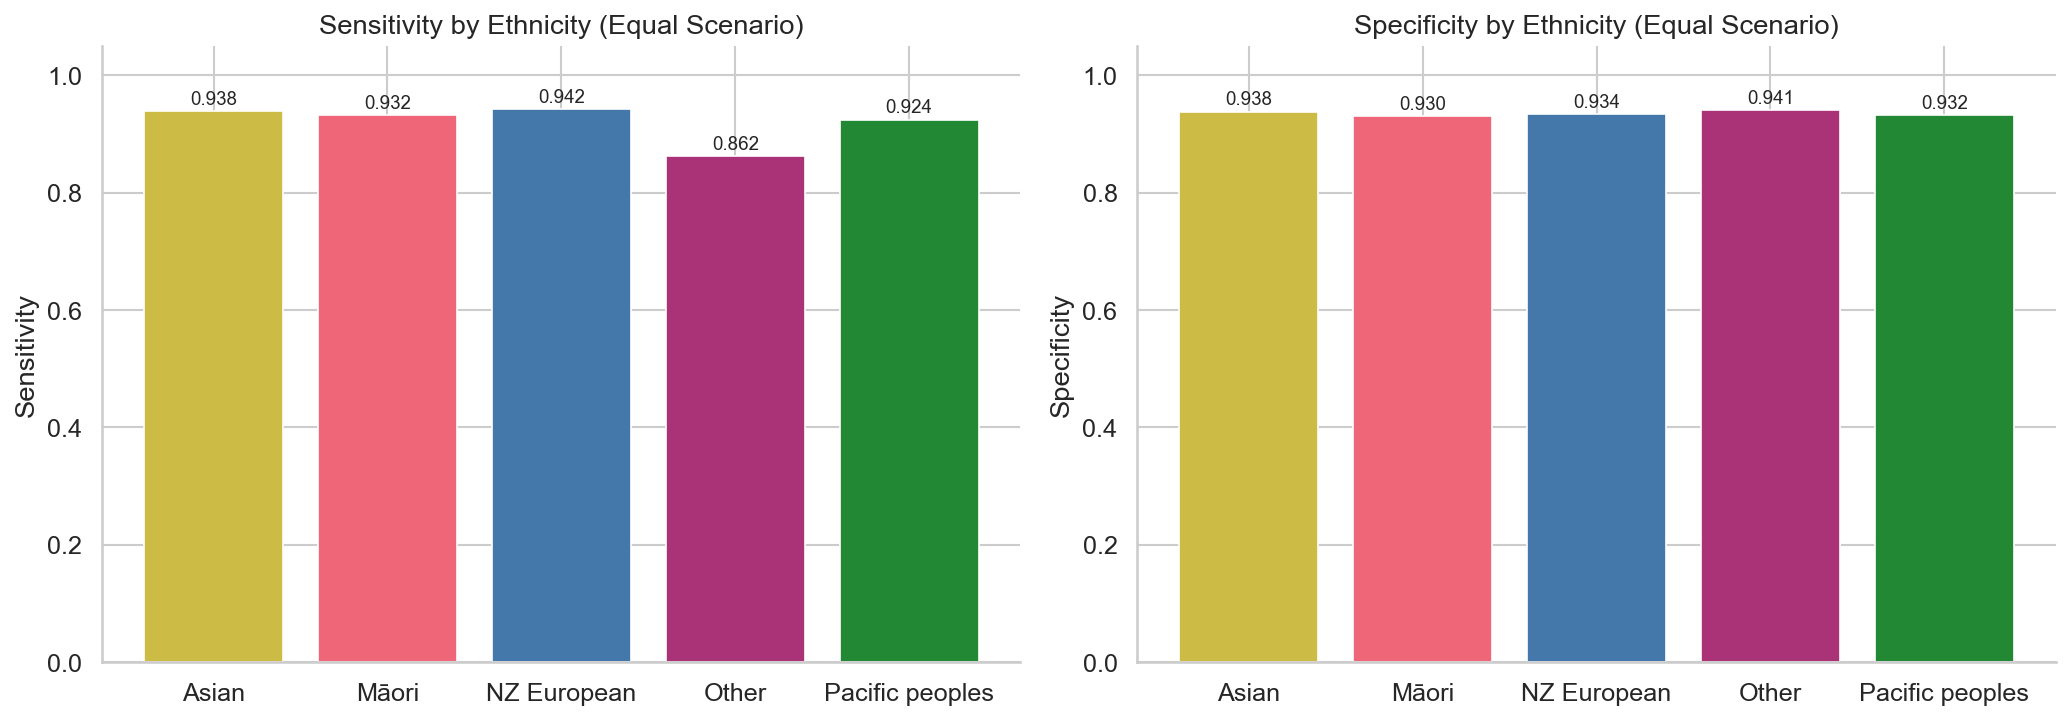

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_stratified_metric(strat_equal, metric="sensitivity", group_col="group",
                       title="Sensitivity by Ethnicity (Equal Scenario)", ax=axes[0])
plot_stratified_metric(strat_equal, metric="specificity", group_col="group",
                       title="Specificity by Ethnicity (Equal Scenario)", ax=axes[1])

plt.tight_layout()
plt.savefig("../outputs/figures/ethnicity_performance_equal.png")
plt.show()

### 2.2 Differential Performance Scenario

In [5]:
strat_diff = stratified_performance(df_diff, "ethnicity")
strat_diff["ethnicity_label"] = strat_diff["group"].map(ETHNICITY_LABELS)
print("Performance by ethnicity (DIFFERENTIAL scenario):")
print(strat_diff[["ethnicity_label", "n", "n_positive", "sensitivity",
                   "specificity", "ppv", "npv", "auc"]].to_string(index=False))

Performance by ethnicity (DIFFERENTIAL scenario):
ethnicity_label    n  n_positive  sensitivity  specificity      ppv      npv      auc
          Asian 1844         130     0.892308     0.889732 0.380328 0.990903 0.963091
          Māori 1611         219     0.894977     0.862787 0.506460 0.981209 0.953731
    NZ European 4833         173     0.924855     0.922532 0.307102 0.996985 0.978525
          Other  501          29     0.827586     0.908898 0.358209 0.988479 0.933372
Pacific peoples 1211         158     0.860759     0.863248 0.485714 0.976369 0.934148


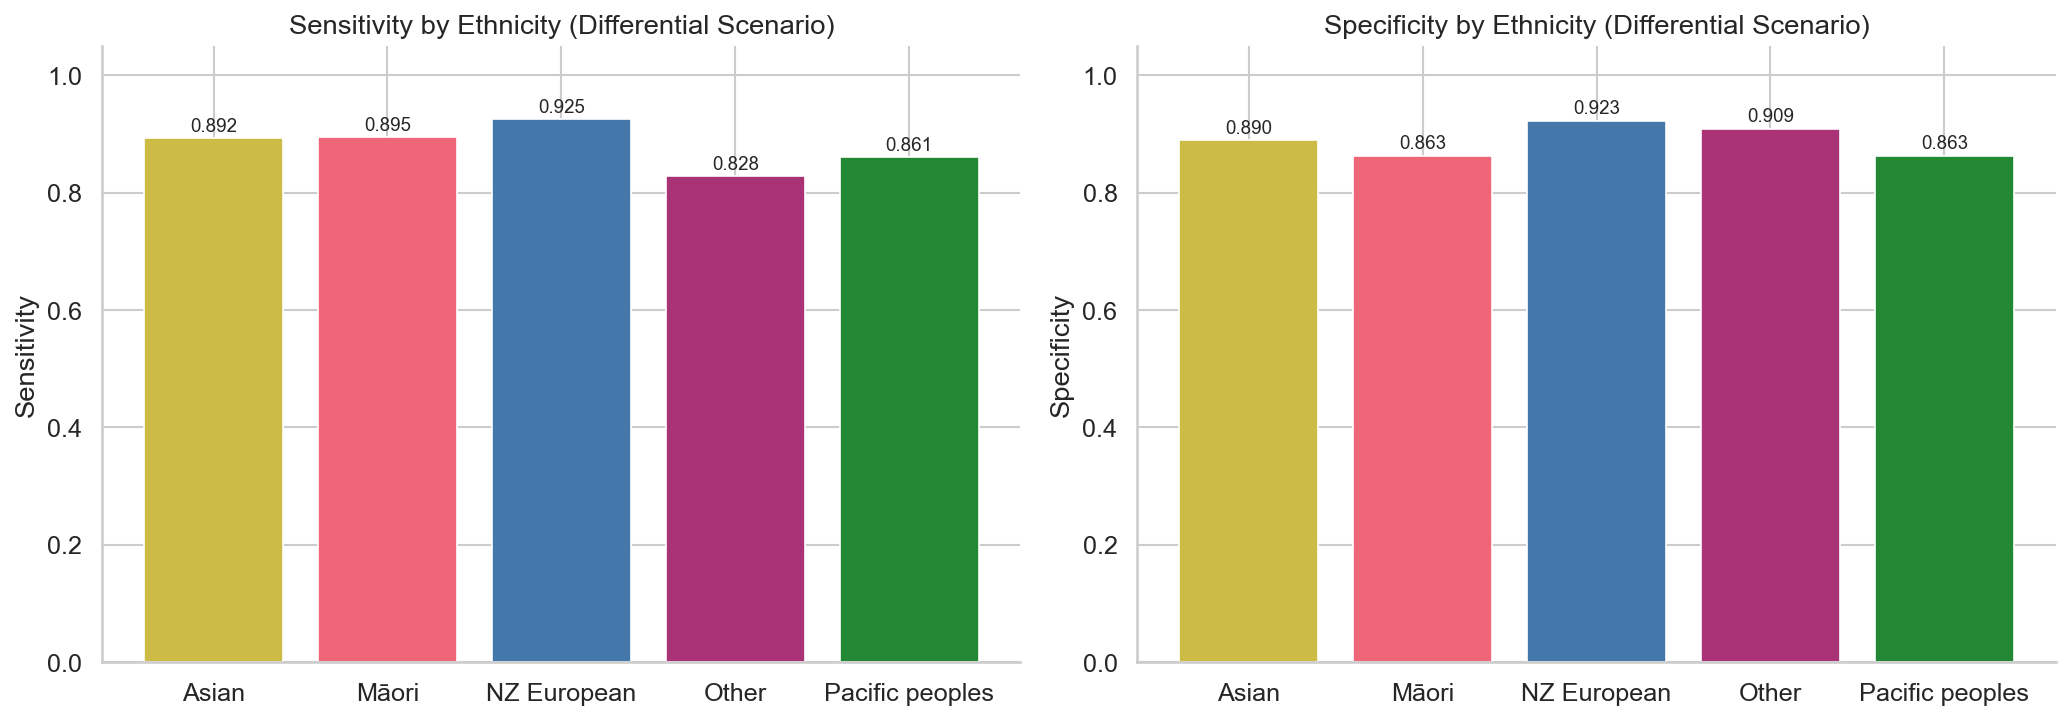

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_stratified_metric(strat_diff, metric="sensitivity", group_col="group",
                       title="Sensitivity by Ethnicity (Differential Scenario)", ax=axes[0])
plot_stratified_metric(strat_diff, metric="specificity", group_col="group",
                       title="Specificity by Ethnicity (Differential Scenario)", ax=axes[1])

plt.tight_layout()
plt.savefig("../outputs/figures/ethnicity_performance_differential.png")
plt.show()

### 2.3 Sensitivity Gap Analysis

Quantifying the gap in sensitivity between NZ European (reference group) and
other ethnic groups under the differential scenario.

In [7]:
gap_df = sensitivity_gap(strat_diff, reference_group="nz_european", metric="sensitivity")
print("Sensitivity gaps relative to NZ European:")
print(gap_df[["ethnicity_label", "sensitivity", "sensitivity_gap",
              "sensitivity_relative_gap"]].to_string(index=False))

Sensitivity gaps relative to NZ European:
ethnicity_label  sensitivity  sensitivity_gap  sensitivity_relative_gap
          Asian     0.892308         0.032548                  0.035192
          Māori     0.894977         0.029878                  0.032306
    NZ European     0.924855         0.000000                  0.000000
          Other     0.827586         0.097269                  0.105172
Pacific peoples     0.860759         0.064096                  0.069304


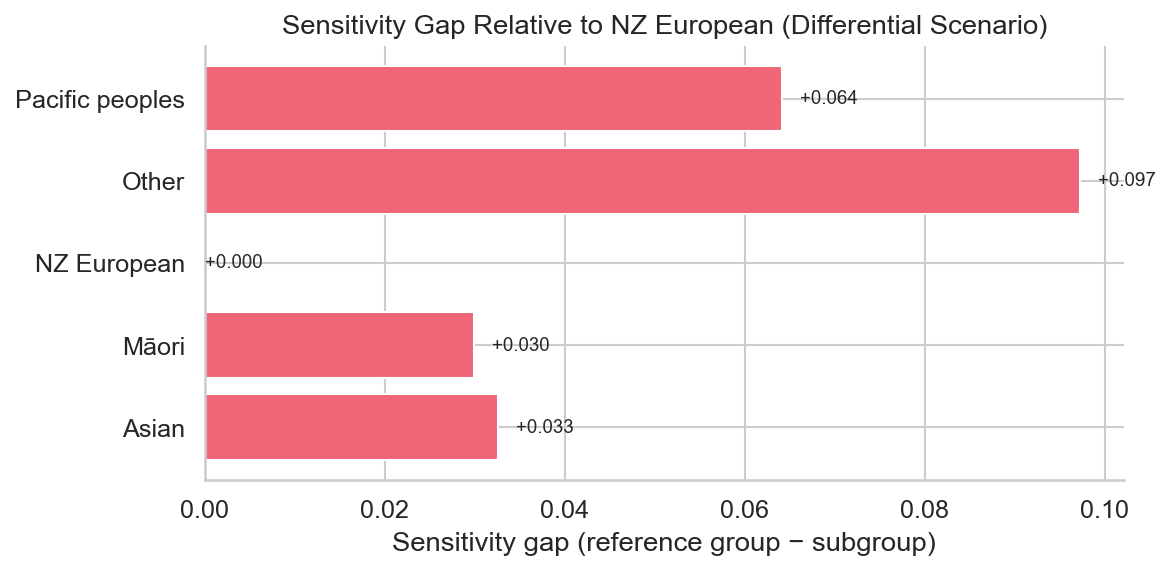

In [8]:
plot_gap_chart(gap_df, metric="sensitivity", group_col="group",
              title="Sensitivity Gap Relative to NZ European (Differential Scenario)",
              save_path="../outputs/figures/sensitivity_gap_ethnicity.png")
plt.show()

### 2.4 Statistical Testing

Two-proportion z-tests comparing sensitivity between NZ European and each
other ethnic group under the differential scenario.

In [9]:
test_results = []
for eth in ["maori", "pacific", "asian", "other"]:
    result = compare_sensitivity_two_groups(
        df_diff, "ethnicity", "nz_european", eth
    )
    result["comparison"] = f"NZ European vs {ETHNICITY_LABELS[eth]}"
    test_results.append(result)

test_df = pd.DataFrame(test_results)[["comparison", "difference", "z", "p_value"]]
print("Two-proportion z-tests for sensitivity differences:")
print(test_df.to_string(index=False))
print("\nNote: p < 0.05 indicates a statistically significant difference.")

Two-proportion z-tests for sensitivity differences:
                    comparison  difference        z  p_value
          NZ European vs Māori    0.029878 1.017110 0.309101
NZ European vs Pacific peoples    0.064096 1.894160 0.058204
          NZ European vs Asian    0.032548 0.984241 0.324997
          NZ European vs Other    0.097269 1.701486 0.088852

Note: p < 0.05 indicates a statistically significant difference.


## 3. Stratified Performance by NZDep Quintile

In [10]:
# NZDep-stratified metrics — differential scenario
strat_nzdep = stratified_performance(df_diff, "nzdep_quintile")
print("Performance by NZDep quintile (DIFFERENTIAL scenario):")
print(strat_nzdep[["group", "n", "n_positive", "sensitivity",
                    "specificity", "auc"]].to_string(index=False))

Performance by NZDep quintile (DIFFERENTIAL scenario):
 group    n  n_positive  sensitivity  specificity      auc
     1 1799          98     0.918367     0.925338 0.970198
     2 1796          94     0.893617     0.917744 0.974623
     3 2022         120     0.933333     0.910620 0.976030
     4 2064         174     0.885057     0.886772 0.952420
     5 2319         223     0.860987     0.867844 0.947941


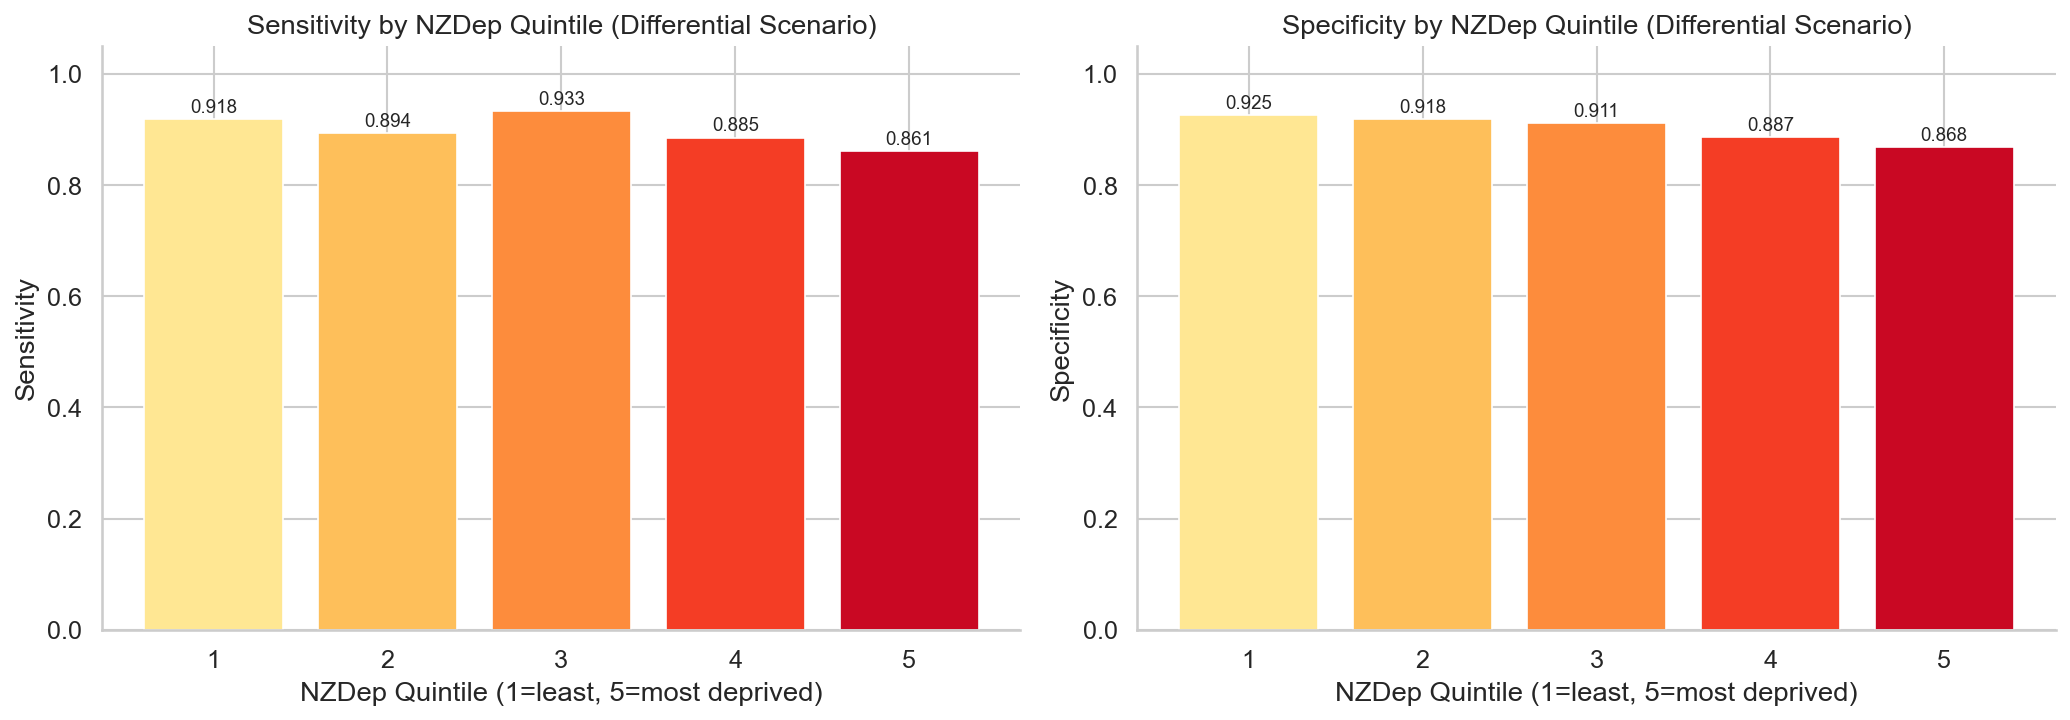

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_stratified_metric(
    strat_nzdep, metric="sensitivity", group_col="group",
    palette=sns.color_palette("YlOrRd", 5),
    title="Sensitivity by NZDep Quintile (Differential Scenario)", ax=axes[0])
axes[0].set_xlabel("NZDep Quintile (1=least, 5=most deprived)")

plot_stratified_metric(
    strat_nzdep, metric="specificity", group_col="group",
    palette=sns.color_palette("YlOrRd", 5),
    title="Specificity by NZDep Quintile (Differential Scenario)", ax=axes[1])
axes[1].set_xlabel("NZDep Quintile (1=least, 5=most deprived)")

plt.tight_layout()
plt.savefig("../outputs/figures/nzdep_performance_differential.png")
plt.show()

## 4. Intersectional Analysis: Ethnicity × NZDep

Populations that experience both ethnic and socioeconomic disadvantage may face
compounded accuracy gaps. This intersectional analysis identifies the subgroups
at greatest risk of underdiagnosis.

In [12]:
intersect = intersectional_analysis(
    df_diff, ["ethnicity", "nzdep_quintile"], min_group_size=30
)
intersect["ethnicity_label"] = intersect["ethnicity"].map(ETHNICITY_LABELS)

# Show the 10 subgroups with lowest sensitivity
print("10 subgroups with lowest sensitivity (min group size = 30):")
worst = intersect.nsmallest(10, "sensitivity")
print(worst[["ethnicity_label", "nzdep_quintile", "n", "n_positive",
             "sensitivity", "specificity"]].to_string(index=False))

10 subgroups with lowest sensitivity (min group size = 30):
ethnicity_label  nzdep_quintile    n  n_positive  sensitivity  specificity
          Other               4   88           6     0.500000     0.902439
          Māori               1  127          13     0.769231     0.807018
          Asian               5  349          27     0.777778     0.866460
          Other               5  108           5     0.800000     0.912621
          Asian               4  422          32     0.812500     0.866667
Pacific peoples               5  637          84     0.833333     0.842676
    NZ European               2 1121          38     0.842105     0.929825
Pacific peoples               3  140          13     0.846154     0.905512
          Māori               2  167          22     0.863636     0.882759
          Other               1   94           9     0.888889     0.941176


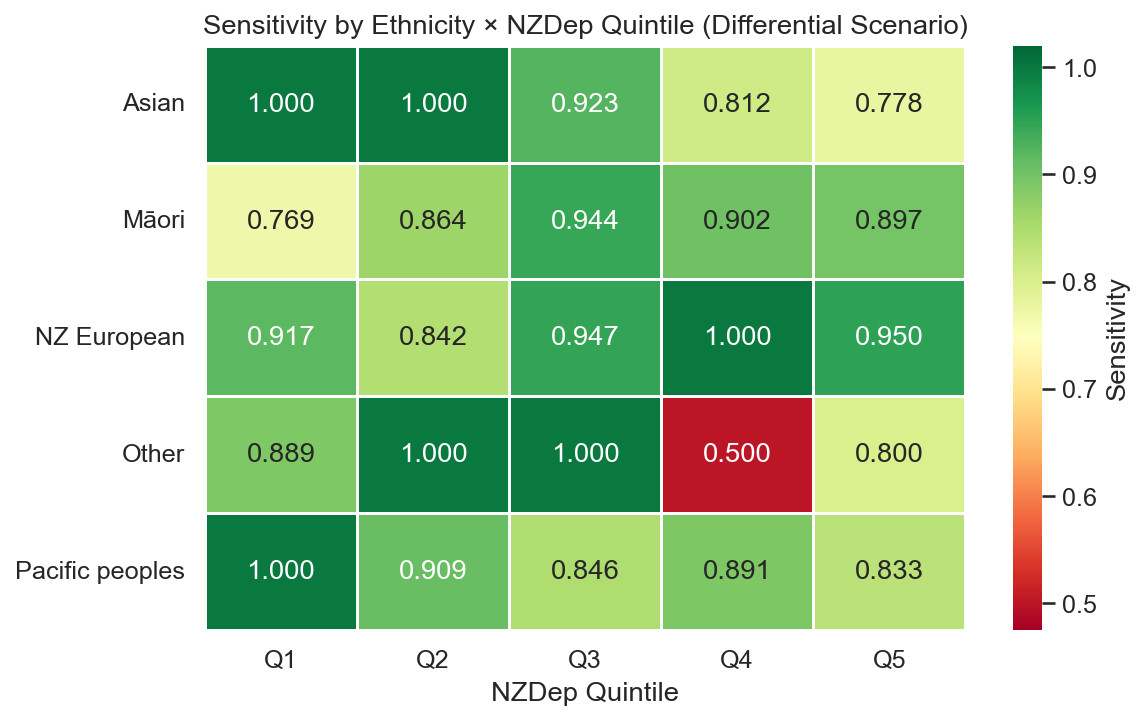

In [13]:
plot_equity_heatmap(
    intersect, row_col="ethnicity", col_col="nzdep_quintile",
    value_col="sensitivity",
    title="Sensitivity by Ethnicity × NZDep Quintile (Differential Scenario)",
    save_path="../outputs/figures/intersectional_heatmap.png",
)
plt.show()

## 5. Equity Summary Statistics

In [14]:
print("=== Equity Summary: Ethnicity (Differential Scenario) ===")
for metric in ["sensitivity", "specificity", "auc"]:
    summ = equity_summary(strat_diff, metric=metric)
    if summ:
        print(f"\n{metric.upper()}:")
        print(f"  Range: {summ['min']:.3f} - {summ['max']:.3f} (gap: {summ['range']:.3f})")
        print(f"  Best: {ETHNICITY_LABELS.get(summ['best_group'], summ['best_group'])}")
        print(f"  Worst: {ETHNICITY_LABELS.get(summ['worst_group'], summ['worst_group'])}")

print("\n=== Equity Summary: NZDep (Differential Scenario) ===")
for metric in ["sensitivity", "specificity", "auc"]:
    summ = equity_summary(strat_nzdep, metric=metric)
    if summ:
        print(f"\n{metric.upper()}:")
        print(f"  Range: {summ['min']:.3f} - {summ['max']:.3f} (gap: {summ['range']:.3f})")
        print(f"  Q least deprived: {summ['best_group']}, Q most deprived: {summ['worst_group']}")

=== Equity Summary: Ethnicity (Differential Scenario) ===

SENSITIVITY:
  Range: 0.828 - 0.925 (gap: 0.097)
  Best: NZ European
  Worst: Other

SPECIFICITY:
  Range: 0.863 - 0.923 (gap: 0.060)
  Best: NZ European
  Worst: Māori

AUC:
  Range: 0.933 - 0.979 (gap: 0.045)
  Best: NZ European
  Worst: Other

=== Equity Summary: NZDep (Differential Scenario) ===

SENSITIVITY:
  Range: 0.861 - 0.933 (gap: 0.072)
  Q least deprived: 3, Q most deprived: 5

SPECIFICITY:
  Range: 0.868 - 0.925 (gap: 0.057)
  Q least deprived: 1, Q most deprived: 5

AUC:
  Range: 0.948 - 0.976 (gap: 0.028)
  Q least deprived: 3, Q most deprived: 5


## 6. Comparison: Equal vs Differential Scenario

To assess the potential impact of subgroup-level performance variation, we
compare overall and worst-subgroup metrics across the two scenarios.

In [15]:
comparison_rows = []
for scenario_name, df_s in [("Equal", df_equal), ("Differential", df_diff)]:
    overall = diagnostic_accuracy(df_s["has_referable_dr"], df_s["ai_prediction"])
    strat = stratified_performance(df_s, "ethnicity")

    comparison_rows.append({
        "Scenario": scenario_name,
        "Overall sensitivity": overall["sensitivity"],
        "Overall specificity": overall["specificity"],
        "Min sensitivity (ethnicity)": strat["sensitivity"].min(),
        "Max sensitivity (ethnicity)": strat["sensitivity"].max(),
        "Sensitivity range": strat["sensitivity"].max() - strat["sensitivity"].min(),
        "Worst group": ETHNICITY_LABELS.get(
            strat.loc[strat["sensitivity"].idxmin(), "group"],
            strat.loc[strat["sensitivity"].idxmin(), "group"]
        ),
    })

comp_df = pd.DataFrame(comparison_rows)
print("Scenario comparison:")
print(comp_df.to_string(index=False))

Scenario comparison:
    Scenario  Overall sensitivity  Overall specificity  Min sensitivity (ethnicity)  Max sensitivity (ethnicity)  Sensitivity range Worst group
       Equal             0.930889             0.934130                     0.862069                     0.942197           0.080128       Other
Differential             0.891396             0.900118                     0.827586                     0.924855           0.097269       Other


## 7. Summary for Health Decision-Makers

### Key Findings

**Overall performance:** Under ideal conditions (equal performance across all
groups), the simulated high-sensitivity AI tool achieves strong diagnostic
accuracy consistent with published clinical trial results. This supports the
potential for AI-assisted DR screening to improve access and efficiency in
Aotearoa New Zealand's screening programme.

**Equity considerations:** Under the differential performance scenario — which
reflects published evidence of AI underdiagnosis in underserved populations —
meaningful gaps emerge:

- **Māori and Pacific peoples** experience lower sensitivity (higher risk of
  missed referable DR) compared to NZ European
- **Patients in the most deprived areas** (NZDep quintile 5) show reduced
  sensitivity compared to the least deprived
- **Intersectional disadvantage** compounds: Pacific peoples in high-deprivation
  areas face the largest accuracy gap

### Implications for Equitable AI Deployment

1. **Pre-deployment testing must include subgroup analysis.** Aggregate accuracy
   metrics can mask clinically important disparities. AI tools should not be
   approved for national deployment based on overall performance alone.

2. **NZ-specific validation is essential.** International trial results may not
   generalise to the NZ population, which has a distinct ethnic composition and
   deprivation profile. The THEIA system (Vaghefi et al., 2022), developed and
   validated on NZ screening data, represents a model for locally relevant
   evaluation.

3. **Ongoing monitoring after deployment.** Even tools that perform equitably
   in trials may show differential real-world performance due to differences in
   image quality, equipment, and patient populations across screening sites.

4. **Equity analysis should be standard.** Every AI tool evaluation in the NZ
   health system should report ethnicity- and deprivation-stratified performance
   as a minimum requirement, aligned with the Health Quality & Safety Commission's
   equity framework and Te Tiriti obligations.

### Limitations

- This is a **simulation study** — results illustrate the evaluation methodology
  and plausible scenarios, not actual measured tool performance in NZ.
- The differential performance modifiers are **illustrative**, based on the
  direction and pattern of bias documented in the literature, not directly
  measured for these specific tools.
- DR prevalence estimates for some ethnic groups rely on limited NZ data
  (Simmons et al., 2007, n=458) and may not reflect current population rates.
- Individual-level demographic data was simulated; real-world screening data
  would provide more precise estimates.

### Next Steps

- Apply this evaluation framework to real AI tool predictions on NZ screening
  data (pending ethics approval and data access)
- Extend to other diagnostic domains where AI is being considered (e.g. radiology)
- Incorporate patient-reported outcomes and access measures alongside accuracy